/tmp/ipykernel_2128022/157855790.py:155: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_t1  = mpl.cm.get_cmap("gray").copy()
/tmp/ipykernel_2128022/157855790.py:156: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m1 = mpl.cm.get_cmap("magma")
/tmp/ipykernel_2128022/157855790.py:157: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m2 = mpl.cm.get_cmap("magma")


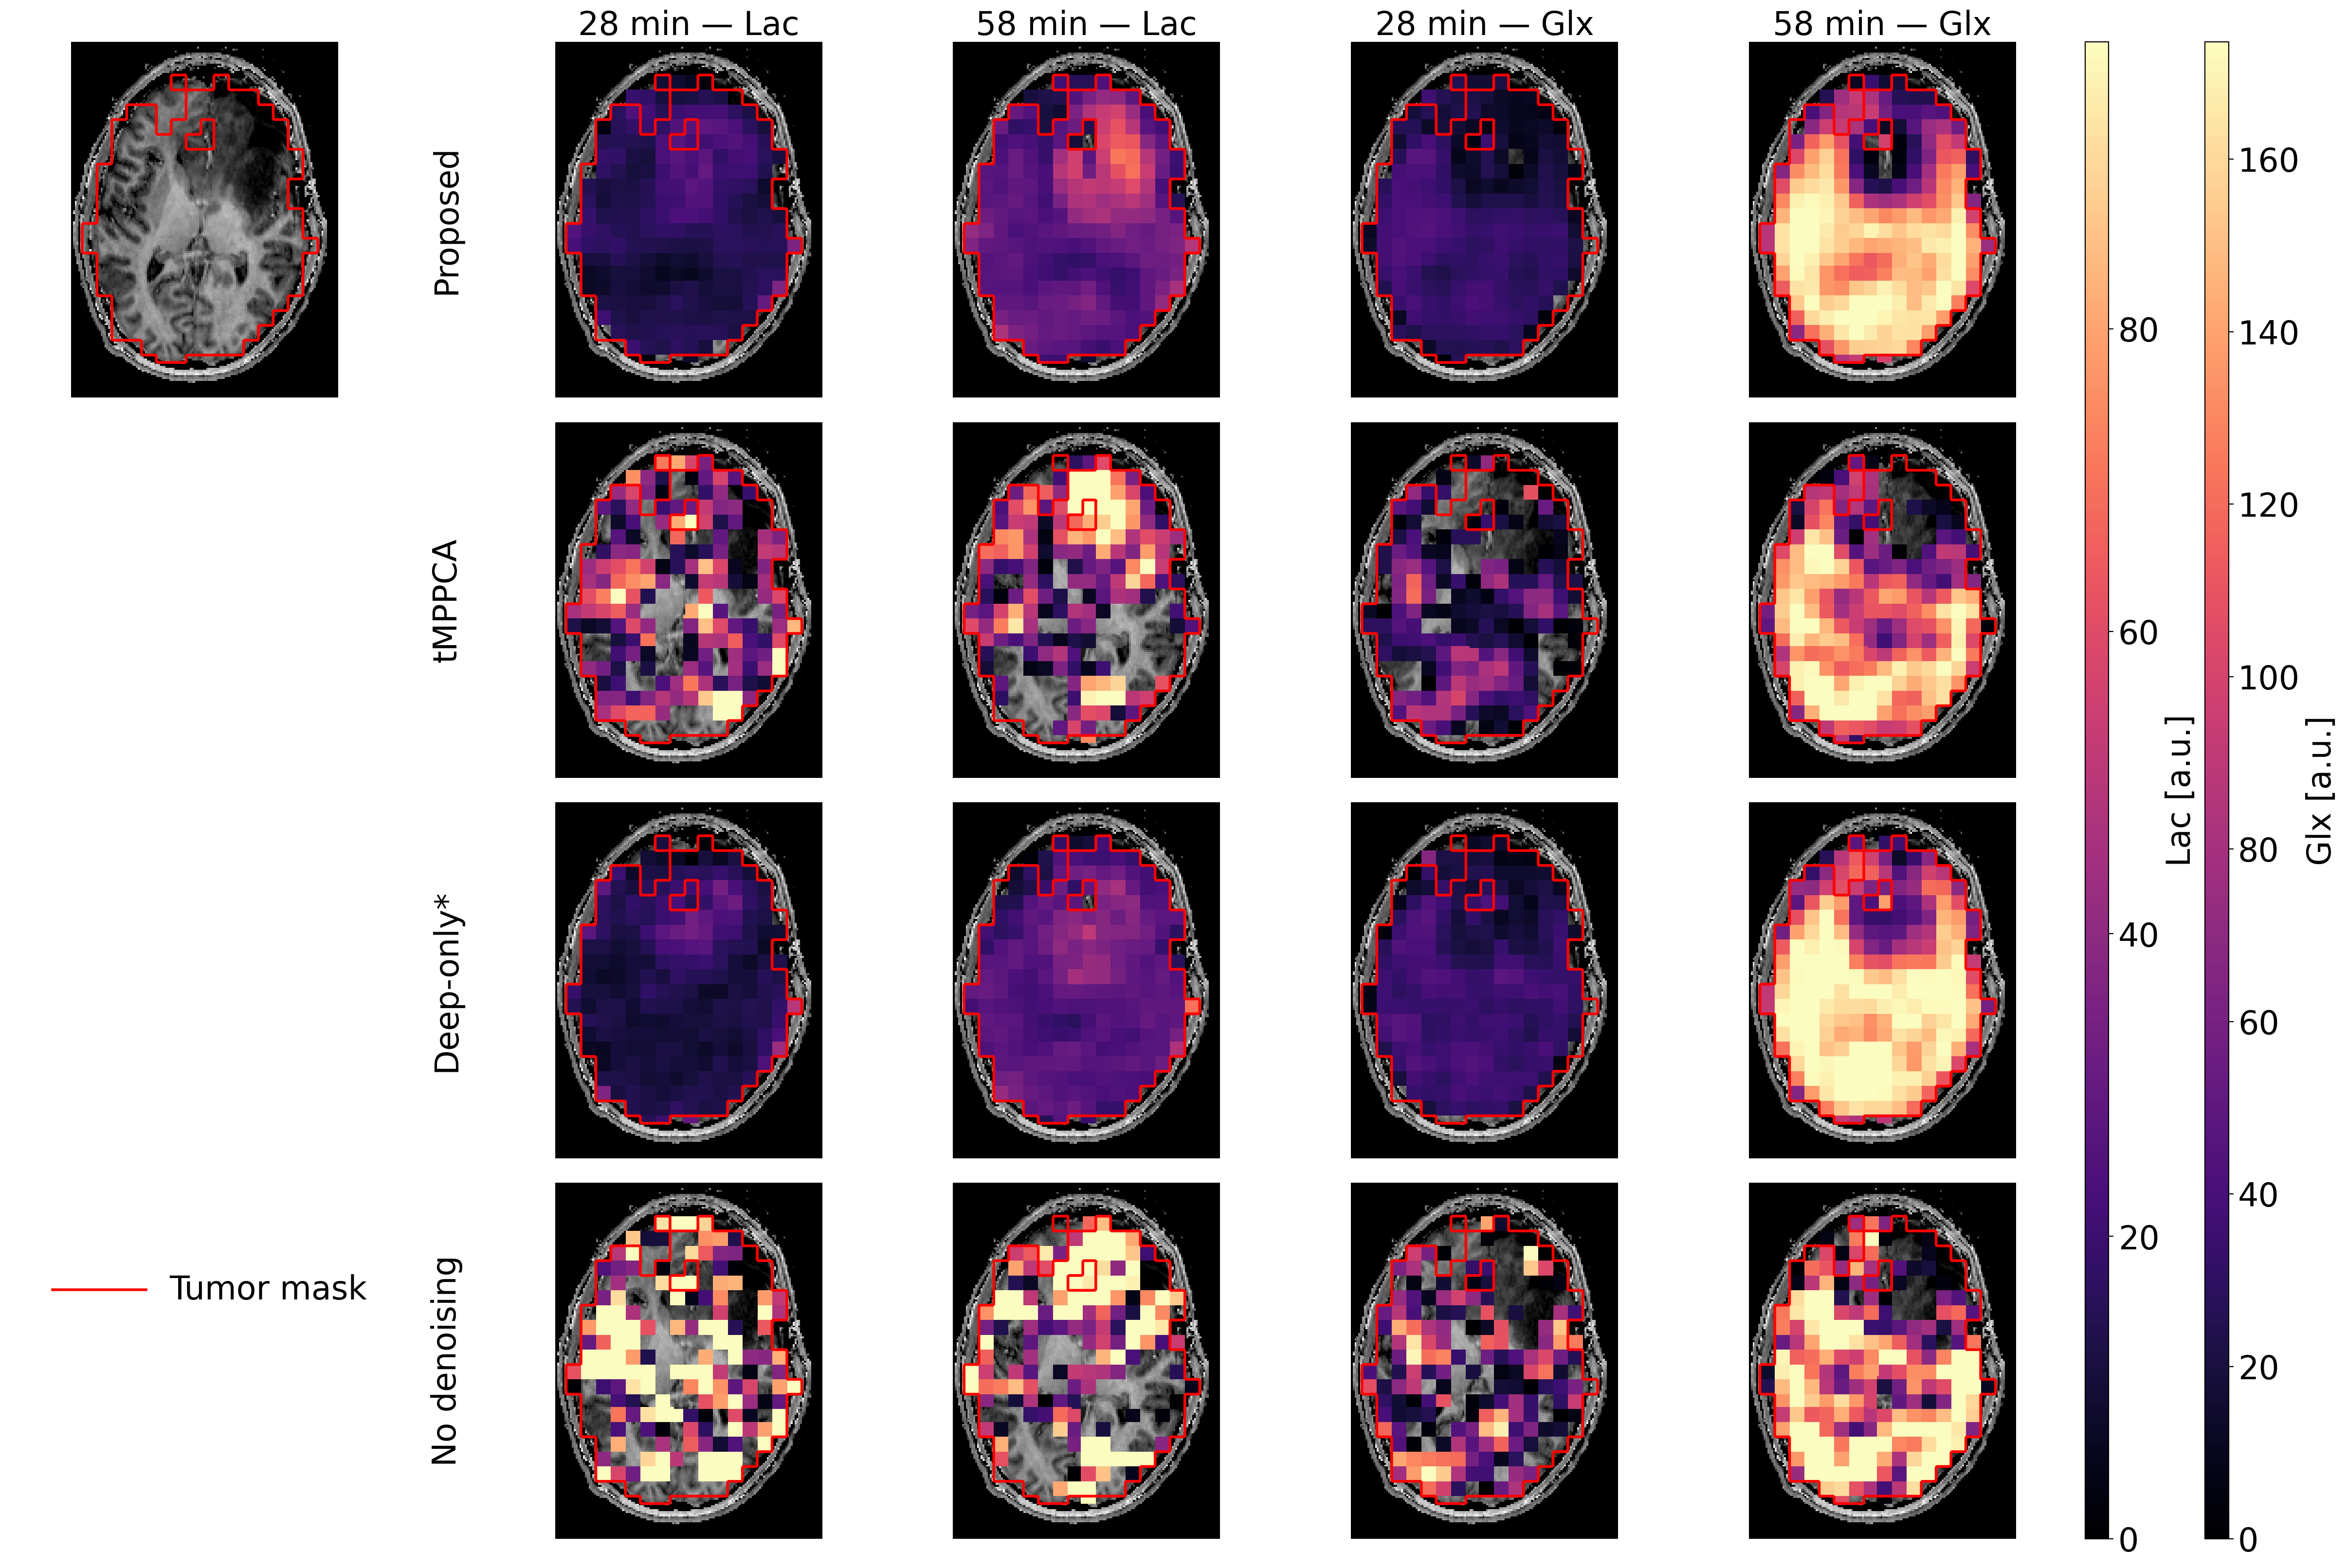

In [4]:
# pip install nibabel matplotlib numpy scikit-image
import os, numpy as np, nibabel as nib
from nibabel.processing import resample_from_to
from skimage import measure
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

def plot_dmi_timecourse_multi(
    BASE_LIST, T_INDEX_LIST,
    T1_Z=106, DMI_Z=11,
    T1_WINDOW=(1268, 3619),
    LINEWIDTH=1.8, figsize_scale=1.0,
    method_labels=None, rep_labels=None,
    fontsize=24,
    DMI_BOX_I=None, DMI_BOX_J=None, box_linewidth=2.0, box_color='white',
    align_t1_to_dmi=True,
    # feste Skalen optional; sonst Auto über alle Methoden/Zeitpunkte (Perzentile)
    LAC_CLIM=None, GLX_CLIM=None, clim_percentiles=(1, 99),
    # frei wählbare Metabolite (Standard: Glc & Glx)
    metabolites=("Glc", "Glx"),
    # Underlay/Overlay Look
    overlay_alpha=0.90,
    overlay_mask_mode="below",   # "below" oder "percentile"
    overlay_mask_value=0.0,      # bei mode="below": maskiert <= overlay_mask_value
    overlay_mask_percentile=5.0, # bei mode="percentile": maskiert unter diesem Perzentil
    # --- NEU: Tumor-Maske ---
    tumor_mask_filename="Tumor_1_mask.nii",  # wird relativ zu BASE/maps/ gesucht
    tumor_mask_path=None,                    # optional: absoluter/relativer Pfad (überschreibt filename)
    tumor_color="red",
    tumor_linewidth=2.0,
    show_tumor_legend=True
):
    """
    metabolites: (metab1, metab2), z.B. ("Glc","Glx") oder ("Lac","Glx")
    Hinweis: LAC_CLIM / GLX_CLIM wirken auf metab1 / metab2 (Namenskompatibilität).

    Design:
    - Weißer Background (Figure + alle Axes)
    - T1 als Underlay, Metab-Map als (maskiertes) Overlay, damit T1 sichtbar bleibt
    - Optional: Tumor-Maske als Kontur (resampled auf T1-Raster)
    """

    assert len(BASE_LIST) >= 1
    if method_labels is not None: assert len(method_labels) == len(BASE_LIST)
    if rep_labels is not None:    assert len(rep_labels) == len(T_INDEX_LIST)
    assert isinstance(metabolites, (list, tuple)) and len(metabolites) == 2
    MET1, MET2 = metabolites[0], metabolites[1]

    # --- T1 aus erster Methode ---
    base0 = BASE_LIST[0]
    T1_PATH = os.path.join(base0, "maps", "magnitude.nii")

    t1_img = nib.load(T1_PATH)
    t1 = t1_img.get_fdata()
    t1_aff, t1_shape = t1_img.affine, t1_img.shape

    # --- Tumor-Maske laden & auf T1 resamplen (NN) ---
    mask_t1_nn = None
    if tumor_mask_path is not None:
        MASK_PATH = tumor_mask_path
    else:
        MASK_PATH = os.path.join(base0, "maps", tumor_mask_filename) if tumor_mask_filename else None

    if MASK_PATH is not None and os.path.exists(MASK_PATH):
        mask_img = nib.load(MASK_PATH)
        mask_t1_nn = resample_from_to(mask_img, (t1_shape, t1_aff), order=0).get_fdata() > 0

    # --- DMI-Z -> T1-Z ---
    def dmi_z_to_t1_z(dmi_img, t1_affine, t1_shape, dmi_z):
        sx, sy, _ = dmi_img.shape
        ijk_dmi = np.array([sx/2.0, sy/2.0, dmi_z, 1.0])
        xyz = dmi_img.affine @ ijk_dmi
        ijk_t1 = np.linalg.inv(t1_affine) @ xyz
        return int(np.clip(np.rint(ijk_t1[2]), 0, t1_shape[2]-1))

    # --- Markierungsbox (affine-sicher) ---
    def draw_dmi_voxel_box_via_resample(ax, dmi_img, i, j, dmi_z, t1_shape, t1_affine,
                                        t1_slice_index, edgecolor='white', lw=2.0):
        if i is None or j is None: return
        shp = dmi_img.shape
        if not (0 <= i < shp[0] and 0 <= j < shp[1] and 0 <= dmi_z < shp[2]): return
        mask_dmi = np.zeros(shp, dtype=np.uint8); mask_dmi[i, j, dmi_z] = 1
        mask_t1 = resample_from_to(nib.Nifti1Image(mask_dmi, dmi_img.affine),
                                   (t1_shape, t1_aff), order=0).get_fdata() > 0
        for c in measure.find_contours(mask_t1[..., t1_slice_index].T.astype(float), 0.5):
            ax.plot(c[:,1], c[:,0], color=edgecolor, linewidth=lw)

    # --- Tumor-Kontur plotten (falls vorhanden) ---
    def draw_tumor_contour(ax, z):
        if mask_t1_nn is None: 
            return
        sl = mask_t1_nn[..., z]
        if not np.any(sl):
            return
        for c in measure.find_contours(sl.T.astype(float), 0.5):
            ax.plot(c[:,1], c[:,0], color=tumor_color, linewidth=tumor_linewidth)

    # --- Loader für Metabolit (auf T1-Raster) ---
    def load_metab_on_t1(BASE, T_index, metab):
        p = os.path.join(BASE, "maps", f"{T_index}", "Orig", f"{metab}_amp_map.nii")
        img = nib.load(p)
        return resample_from_to(img, (t1_shape, t1_aff), order=0).get_fdata()

    # --- Overlay-Maske, damit T1 sichtbar bleibt ---
    def masked_overlay(vol3d, z, mode="below", value=0.0, percentile=5.0):
        sl = vol3d[..., z]
        if mode == "below":
            m = ~np.isfinite(sl) | (sl <= value)
        elif mode == "percentile":
            finite = sl[np.isfinite(sl)]
            if finite.size == 0:
                m = ~np.isfinite(sl)
            else:
                thr = np.percentile(finite, percentile)
                m = ~np.isfinite(sl) | (sl <= thr)
        else:
            m = ~np.isfinite(sl)
        return np.ma.array(sl, mask=m)

    # globale DMI→T1-Slice (nutze MET1 als Referenz)
    ref_img_for_z = nib.load(os.path.join(BASE_LIST[0], "maps", f"{T_INDEX_LIST[0]}", "Orig", f"{MET1}_amp_map.nii"))
    T1_Z_MATCH_GLOBAL = dmi_z_to_t1_z(ref_img_for_z, t1_aff, t1_shape, DMI_Z)

    # --- Auto-CLIMs ---
    def gather_vals(metab):
        vals = []
        for B in BASE_LIST:
            for T in T_INDEX_LIST:
                a = load_metab_on_t1(B, T, metab)
                vals.append(a[np.isfinite(a)])
        vals = np.concatenate(vals) if len(vals) > 1 else vals[0]
        p1, p99 = np.percentile(vals, clim_percentiles)
        if p1 == p99: p99 = p1 + 1.0
        return (float(p1), float(p99))

    M1_CLIM = LAC_CLIM if LAC_CLIM is not None else gather_vals(MET1)
    M2_CLIM = GLX_CLIM if GLX_CLIM is not None else gather_vals(MET2)

    # === Layout: T1 | Label | (alle MET1) | (alle MET2) | Cbar MET1 | Cbar MET2 ===
    n_times = len(T_INDEX_LIST)
    nrows = len(BASE_LIST)
    ncols = 1 + 1 + n_times + n_times + 2

    fig_w = figsize_scale * (ncols * 3.0)
    fig_h = figsize_scale * (nrows * 4.0)
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=200, constrained_layout=True)

    # weißer Hintergrund (wie in deinem healthy design)
    fig.patch.set_facecolor('white')

    width_ratios = [1, 0.2] + [1]*n_times + [1]*n_times + [0.06, 0.06]
    gs = GridSpec(nrows, ncols, figure=fig, width_ratios=width_ratios, height_ratios=[1]*nrows)

    cmap_t1  = mpl.cm.get_cmap("gray").copy()
    cmap_m1 = mpl.cm.get_cmap("magma")
    cmap_m2 = mpl.cm.get_cmap("magma")
    norm_m1 = mpl.colors.Normalize(vmin=M1_CLIM[0], vmax=M1_CLIM[1], clip=True)
    norm_m2 = mpl.colors.Normalize(vmin=M2_CLIM[0], vmax=M2_CLIM[1], clip=True)
    t1_vmin, t1_vmax = T1_WINDOW

    last_im_m1 = None
    last_im_m2 = None

    for r, BASE in enumerate(BASE_LIST):
        ref_img = nib.load(os.path.join(BASE, "maps", f"{T_INDEX_LIST[0]}", "Orig", f"{MET1}_amp_map.nii"))
        T1_Z_MATCH = dmi_z_to_t1_z(ref_img, t1_aff, t1_shape, DMI_Z)

        # T1 (nur erste Zeile)
        if r == 0:
            ax_t1 = fig.add_subplot(gs[r, 0]); ax_t1.axis('off')
            ax_t1.set_facecolor('white')
            zshow = T1_Z_MATCH_GLOBAL if align_t1_to_dmi else T1_Z
            ax_t1.imshow(t1[..., zshow].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                         origin='lower', interpolation='nearest')
            # Tumor-Kontur auf T1
            draw_tumor_contour(ax_t1, zshow)

            if DMI_BOX_I is not None and DMI_BOX_J is not None:
                draw_dmi_voxel_box_via_resample(ax_t1, ref_img_for_z, DMI_BOX_I, DMI_BOX_J, DMI_Z,
                                                t1_shape, t1_aff, zshow, edgecolor=box_color, lw=box_linewidth)
        else:
            ax_blank = fig.add_subplot(gs[r, 0]); ax_blank.axis('off'); ax_blank.set_facecolor('white')

        # vertikales Methodenlabel
        ax_label = fig.add_subplot(gs[r, 1]); ax_label.axis('off'); ax_label.set_facecolor('white')
        label = method_labels[r] if method_labels is not None else os.path.basename(os.path.normpath(BASE))
        ax_label.text(0.5, 0.5, label, color='black', fontsize=fontsize,
                      rotation=90, ha='center', va='center', transform=ax_label.transAxes)

        # --- MET1 ---
        for j, T in enumerate(T_INDEX_LIST):
            ax = fig.add_subplot(gs[r, 2 + j]); ax.axis('off'); ax.set_facecolor('white')

            ax.imshow(t1[..., T1_Z_MATCH].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                      origin='lower', interpolation='nearest')

            m1 = load_metab_on_t1(BASE, T, MET1)
            m1_sl = masked_overlay(m1, T1_Z_MATCH, mode=overlay_mask_mode,
                                   value=overlay_mask_value, percentile=overlay_mask_percentile)
            last_im_m1 = ax.imshow(m1_sl.T, cmap=cmap_m1, norm=norm_m1,
                                   origin='lower', interpolation='nearest', alpha=overlay_alpha)

            # Tumor-Kontur
            draw_tumor_contour(ax, T1_Z_MATCH)

            if r == 0:
                tlabel = rep_labels[j] if rep_labels is not None else f"T={T}"
                ax.set_title(f"{tlabel} — {MET1}", color='black', fontsize=fontsize, pad=4)

        # --- MET2 ---
        m2_offset = 2 + n_times
        for j, T in enumerate(T_INDEX_LIST):
            ax = fig.add_subplot(gs[r, m2_offset + j]); ax.axis('off'); ax.set_facecolor('white')

            ax.imshow(t1[..., T1_Z_MATCH].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                      origin='lower', interpolation='nearest')

            m2 = load_metab_on_t1(BASE, T, MET2)
            m2_sl = masked_overlay(m2, T1_Z_MATCH, mode=overlay_mask_mode,
                                   value=overlay_mask_value, percentile=overlay_mask_percentile)
            last_im_m2 = ax.imshow(m2_sl.T, cmap=cmap_m2, norm=norm_m2,
                                   origin='lower', interpolation='nearest', alpha=overlay_alpha)

            # Tumor-Kontur
            draw_tumor_contour(ax, T1_Z_MATCH)

            if r == 0:
                tlabel = rep_labels[j] if rep_labels is not None else f"T={T}"
                ax.set_title(f"{tlabel} — {MET2}", color='black', fontsize=fontsize, pad=4)

    # --- zwei globale Colorbars ---
    cax_m1 = fig.add_subplot(gs[:, ncols-2]); cax_m1.set_facecolor('white')
    if last_im_m1 is not None:
        cbar_m1 = fig.colorbar(last_im_m1, cax=cax_m1)
        cbar_m1.ax.set_facecolor('white')
        cbar_m1.outline.set_edgecolor('black')
        plt.setp(cbar_m1.ax.get_yticklabels(), color='black', fontsize=fontsize)
        cbar_m1.set_label(f"{MET1} [a.u.]", color='black', fontsize=fontsize)

    cax_m2 = fig.add_subplot(gs[:, ncols-1]); cax_m2.set_facecolor('white')
    if last_im_m2 is not None:
        cbar_m2 = fig.colorbar(last_im_m2, cax=cax_m2)
        cbar_m2.ax.set_facecolor('white')
        cbar_m2.outline.set_edgecolor('black')
        plt.setp(cbar_m2.ax.get_yticklabels(), color='black', fontsize=fontsize)
        cbar_m2.set_label(f"{MET2} [a.u.]", color='black', fontsize=fontsize)

    # --- Legende unten links (Tumor + Marked voxel) ---
    legend_x, legend_y, legend_dx = 0.02, 0.175, 0.04

    if show_tumor_legend and (mask_t1_nn is not None):
        fig.add_artist(plt.Line2D([legend_x, legend_x + legend_dx],
                                  [legend_y, legend_y],
                                  color=tumor_color, linewidth=tumor_linewidth,
                                  transform=fig.transFigure, figure=fig))
        fig.text(legend_x + legend_dx + 0.01, legend_y, "Tumor mask",
                 color='black', va='center', fontsize=fontsize, transform=fig.transFigure)

        # Abstand nach unten für voxel-legende
        legend_y2 = legend_y - 0.03
    else:
        legend_y2 = legend_y

    # Marked voxel (falls genutzt)
    fig.add_artist(plt.Line2D([legend_x, legend_x + legend_dx],
                              [legend_y2, legend_y2],
                              color=box_color, linewidth=max(box_linewidth, 1.0),
                              transform=fig.transFigure, figure=fig))
    # optional Text (wenn du ihn willst, einfach entkommentieren)
    # fig.text(legend_x + legend_dx + 0.01, legend_y2, "Marked voxel",
    #          color='black', va='center', fontsize=fontsize, transform=fig.transFigure)

    plt.show()
    fig.savefig("output.pdf", bbox_inches='tight', facecolor=fig.get_facecolor())


plot_dmi_timecourse_multi(
    BASE_LIST=[
        "MetabMaps/Tumor_1_deep_tMPPCA_5D",
        "MetabMaps/Tumor_1_tMPPCA_5D",
        "MetabMaps/Tumor_1_FullRank_deep",
        "MetabMaps/Tumor_1_noisy"
    ],
    T_INDEX_LIST=[4, 10],
    method_labels=["Proposed", "tMPPCA","Deep-only*", "No denoising"],
    rep_labels=["28 min", "58 min"],
    DMI_Z=10,
    align_t1_to_dmi=True,
    metabolites=("Lac", "Glx"),
    overlay_alpha=1.0,
    overlay_mask_mode="percentile",
    overlay_mask_percentile=5.0,
    tumor_mask_filename="Tumor_1_mask.nii",
    tumor_color="red",
    tumor_linewidth=2.0
)

/tmp/ipykernel_2128022/2742701965.py:171: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_t1  = mpl.cm.get_cmap("gray").copy()
/tmp/ipykernel_2128022/2742701965.py:172: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m1  = mpl.cm.get_cmap("magma")
/tmp/ipykernel_2128022/2742701965.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_m2  = mpl.cm.get_cmap("magma")
/tmp/ipykernel_2128022/2742701965.py:174: MatplotlibDeprecationWarning: The get_cmap fun

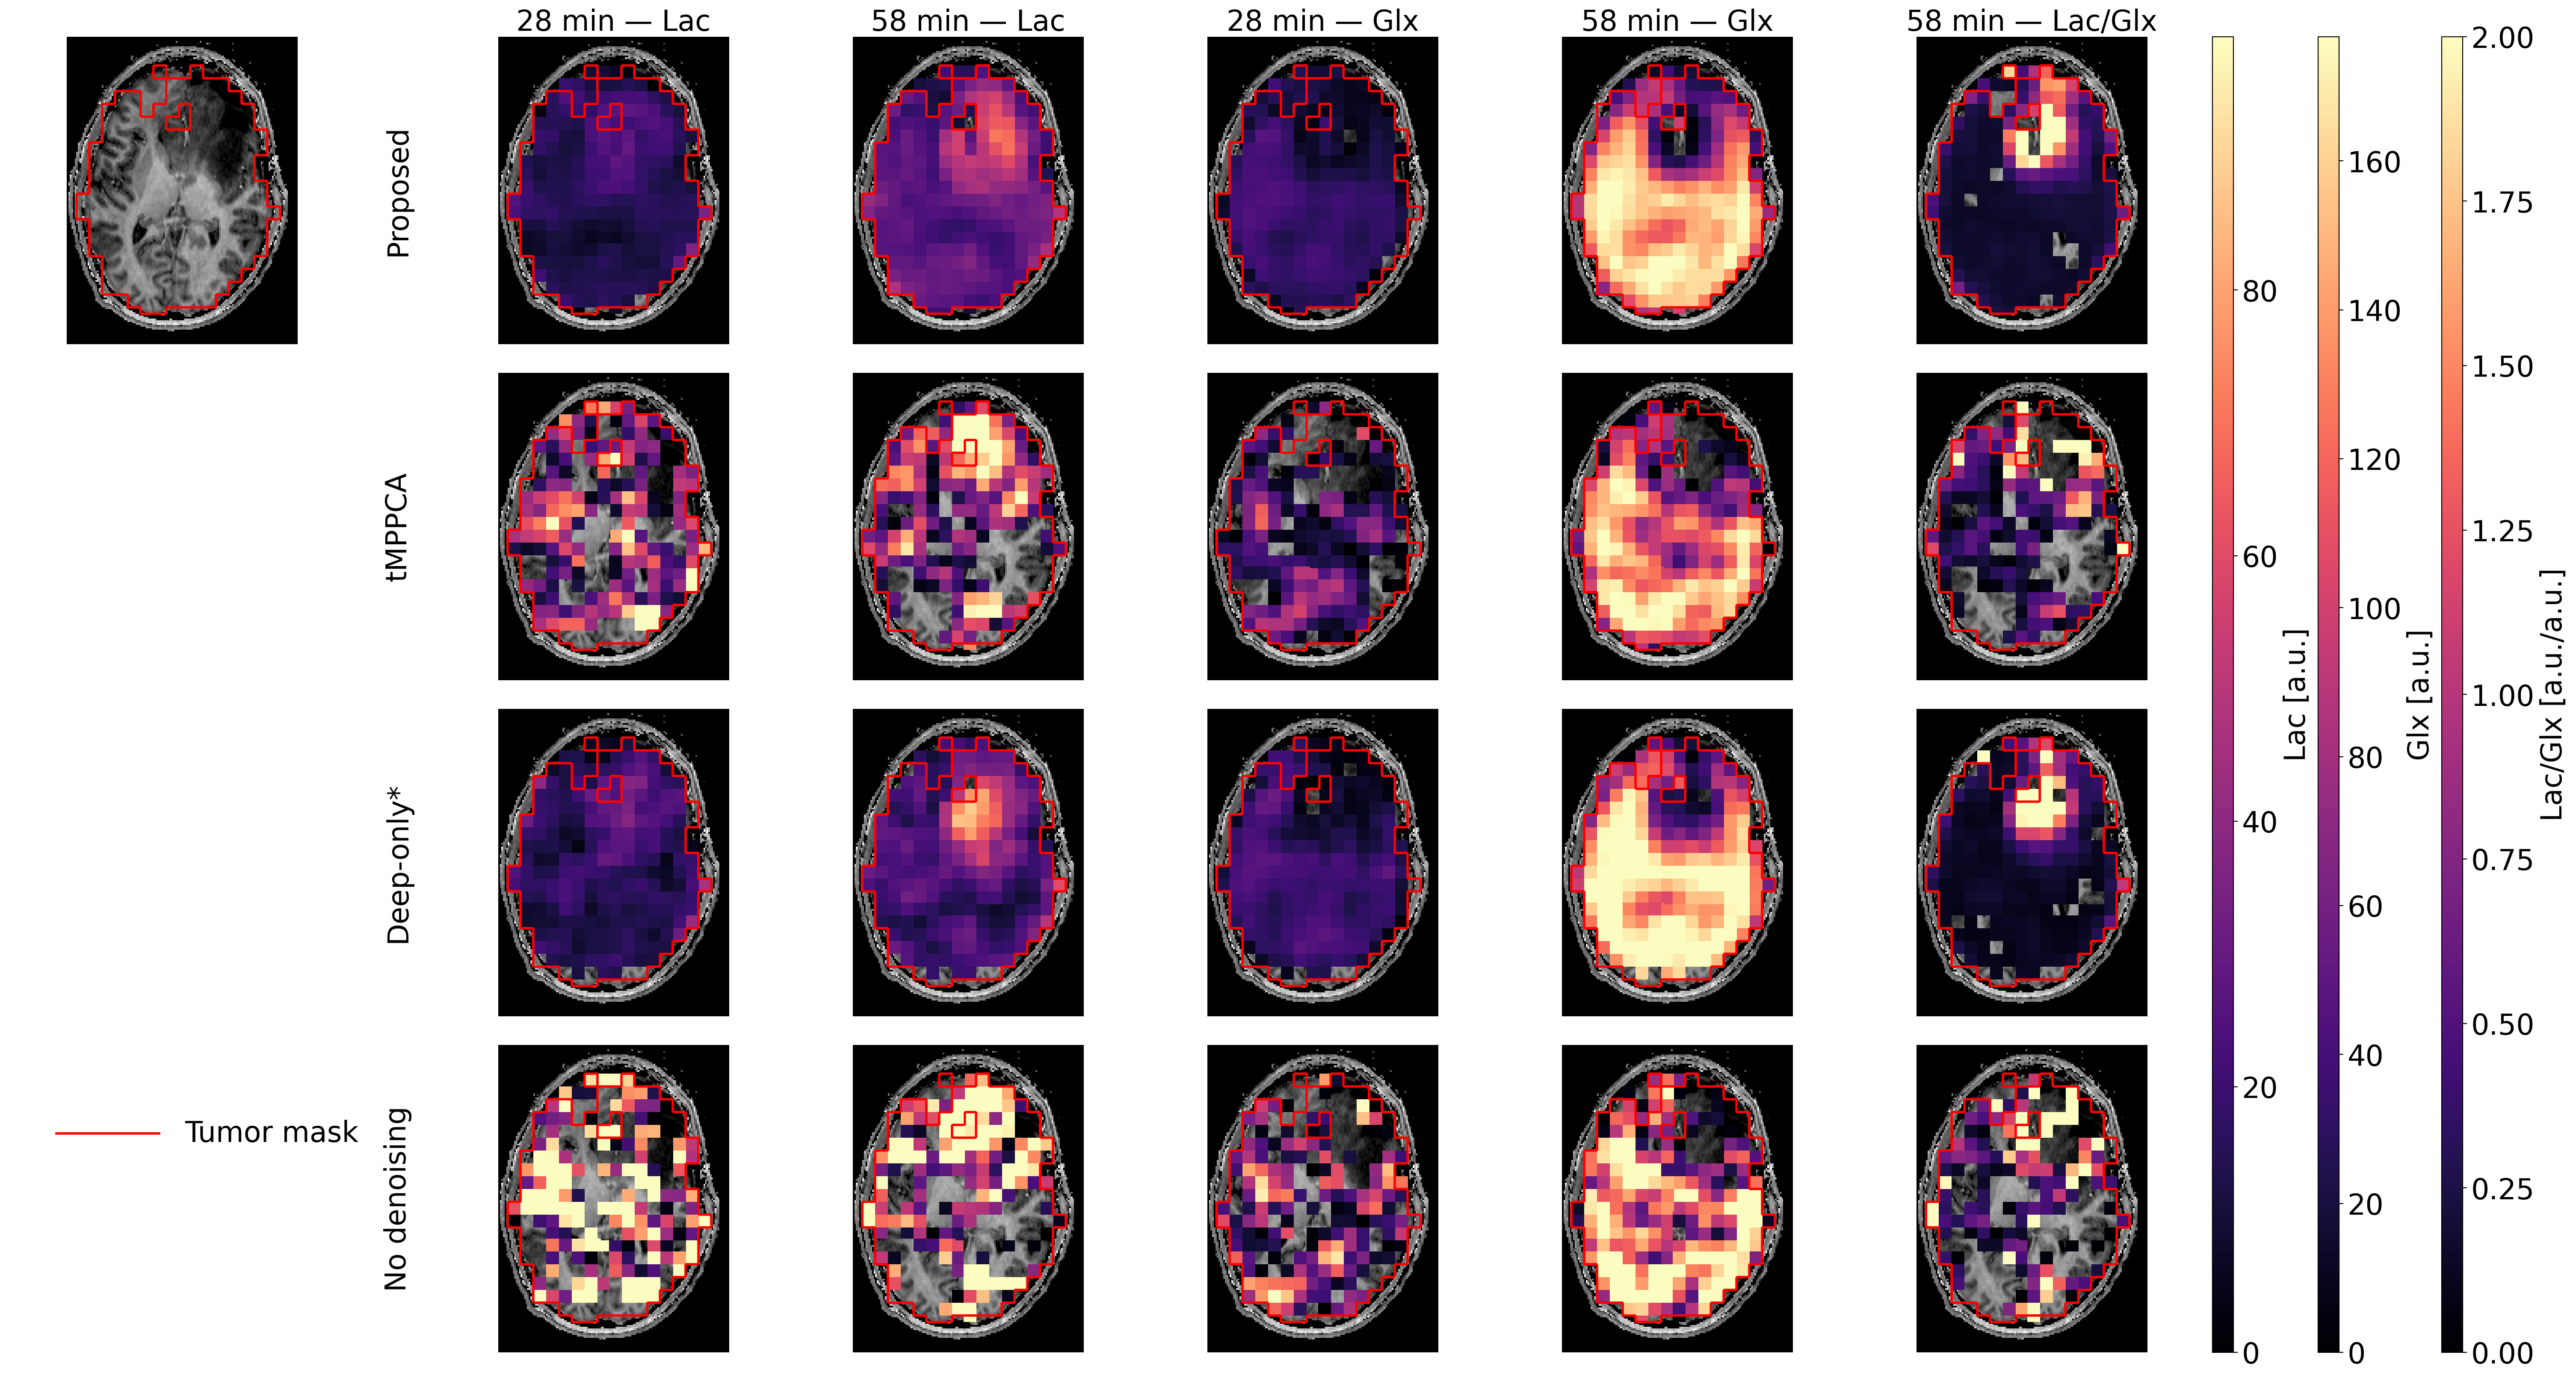

In [ ]:
# pip install nibabel matplotlib numpy scikit-image
import os, numpy as np, nibabel as nib
from nibabel.processing import resample_from_to
from skimage import measure
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

def plot_dmi_timecourse_multi(
    BASE_LIST, T_INDEX_LIST,
    T1_Z=106, DMI_Z=11,
    T1_WINDOW=(1268, 3619),
    LINEWIDTH=1.8, figsize_scale=1.0,
    method_labels=None, rep_labels=None,
    fontsize=24,
    DMI_BOX_I=None, DMI_BOX_J=None, box_linewidth=2.0, box_color='white',
    align_t1_to_dmi=True,
    # feste Skalen optional; sonst Auto über alle Methoden/Zeitpunkte (Perzentile)
    LAC_CLIM=None, GLX_CLIM=None, clim_percentiles=(1, 99),
    # frei wählbare Metabolite (Standard: Glc & Glx)
    metabolites=("Glc", "Glx"),
    # Underlay/Overlay Look
    overlay_alpha=0.90,
    overlay_mask_mode="below",   # "below" oder "percentile"
    overlay_mask_value=0.0,      # bei mode="below": maskiert <= overlay_mask_value
    overlay_mask_percentile=5.0, # bei mode="percentile": maskiert unter diesem Perzentil
    # --- NEU: Tumor-Maske ---
    tumor_mask_filename="Tumor_1_mask.nii",  # wird relativ zu BASE/maps/ gesucht
    tumor_mask_path=None,                    # optional: absoluter/relativer Pfad (überschreibt filename)
    tumor_color="red",
    tumor_linewidth=2.0,
    show_tumor_legend=True,
    # --- NEU: Ratio-Spalte ---
    add_ratio_column=True,
    ratio_name="Lac/Glx",
    ratio_metabs=("Lac", "Glx"),   # Numerator, Denominator
    ratio_clim=(0.0, 2.0),         # feste Colorbar 0..2
    ratio_eps=0.0                  # optional: denom <= eps wird maskiert (standard: <=0)
):
    """
    metabolites: (metab1, metab2), z.B. ("Glc","Glx") oder ("Lac","Glx")
    Hinweis: LAC_CLIM / GLX_CLIM wirken auf metab1 / metab2 (Namenskompatibilität).

    Design:
    - Weißer Background (Figure + alle Axes)
    - T1 als Underlay, Metab-Map als (maskiertes) Overlay, damit T1 sichtbar bleibt
    - Optional: Tumor-Maske als Kontur (resampled auf T1-Raster)
    - Optional: zusätzliche Ratio-Spalte ganz rechts (nur letzter Zeitpunkt)
    """

    assert len(BASE_LIST) >= 1
    if method_labels is not None: assert len(method_labels) == len(BASE_LIST)
    if rep_labels is not None:    assert len(rep_labels) == len(T_INDEX_LIST)
    assert isinstance(metabolites, (list, tuple)) and len(metabolites) == 2
    MET1, MET2 = metabolites[0], metabolites[1]

    # --- T1 aus erster Methode ---
    base0 = BASE_LIST[0]
    T1_PATH = os.path.join(base0, "maps", "magnitude.nii")

    t1_img = nib.load(T1_PATH)
    t1 = t1_img.get_fdata()
    t1_aff, t1_shape = t1_img.affine, t1_img.shape

    # --- Tumor-Maske laden & auf T1 resamplen (NN) ---
    mask_t1_nn = None
    if tumor_mask_path is not None:
        MASK_PATH = tumor_mask_path
    else:
        MASK_PATH = os.path.join(base0, "maps", tumor_mask_filename) if tumor_mask_filename else None

    if MASK_PATH is not None and os.path.exists(MASK_PATH):
        mask_img = nib.load(MASK_PATH)
        mask_t1_nn = resample_from_to(mask_img, (t1_shape, t1_aff), order=0).get_fdata() > 0

    # --- DMI-Z -> T1-Z ---
    def dmi_z_to_t1_z(dmi_img, t1_affine, t1_shape, dmi_z):
        sx, sy, _ = dmi_img.shape
        ijk_dmi = np.array([sx/2.0, sy/2.0, dmi_z, 1.0])
        xyz = dmi_img.affine @ ijk_dmi
        ijk_t1 = np.linalg.inv(t1_affine) @ xyz
        return int(np.clip(np.rint(ijk_t1[2]), 0, t1_shape[2]-1))

    # --- Markierungsbox (affine-sicher) ---
    def draw_dmi_voxel_box_via_resample(ax, dmi_img, i, j, dmi_z, t1_shape, t1_affine,
                                        t1_slice_index, edgecolor='white', lw=2.0):
        if i is None or j is None: return
        shp = dmi_img.shape
        if not (0 <= i < shp[0] and 0 <= j < shp[1] and 0 <= dmi_z < shp[2]): return
        mask_dmi = np.zeros(shp, dtype=np.uint8); mask_dmi[i, j, dmi_z] = 1
        mask_t1 = resample_from_to(nib.Nifti1Image(mask_dmi, dmi_img.affine),
                                   (t1_shape, t1_aff), order=0).get_fdata() > 0
        for c in measure.find_contours(mask_t1[..., t1_slice_index].T.astype(float), 0.5):
            ax.plot(c[:,1], c[:,0], color=edgecolor, linewidth=lw)

    # --- Tumor-Kontur plotten (falls vorhanden) ---
    def draw_tumor_contour(ax, z):
        if mask_t1_nn is None:
            return
        sl = mask_t1_nn[..., z]
        if not np.any(sl):
            return
        for c in measure.find_contours(sl.T.astype(float), 0.5):
            ax.plot(c[:,1], c[:,0], color=tumor_color, linewidth=tumor_linewidth)

    # --- Loader für Metabolit (auf T1-Raster) ---
    def load_metab_on_t1(BASE, T_index, metab):
        p = os.path.join(BASE, "maps", f"{T_index}", "Orig", f"{metab}_amp_map.nii")
        img = nib.load(p)
        return resample_from_to(img, (t1_shape, t1_aff), order=0).get_fdata()

    # --- Overlay-Maske, damit T1 sichtbar bleibt ---
    def masked_overlay(vol3d, z, mode="below", value=0.0, percentile=5.0):
        sl = vol3d[..., z]
        if mode == "below":
            m = ~np.isfinite(sl) | (sl <= value)
        elif mode == "percentile":
            finite = sl[np.isfinite(sl)]
            if finite.size == 0:
                m = ~np.isfinite(sl)
            else:
                thr = np.percentile(finite, percentile)
                m = ~np.isfinite(sl) | (sl <= thr)
        else:
            m = ~np.isfinite(sl)
        return np.ma.array(sl, mask=m)

    # --- Ratio map (auf T1-Raster) ---
    def load_ratio_on_t1(BASE, T_index, num_metab, den_metab, eps=0.0):
        num = load_metab_on_t1(BASE, T_index, num_metab)
        den = load_metab_on_t1(BASE, T_index, den_metab)
        r = np.full_like(num, np.nan, dtype=np.float32)
        ok = np.isfinite(num) & np.isfinite(den) & (den > eps)
        r[ok] = num[ok] / den[ok]
        return r

    # globale DMI→T1-Slice (nutze MET1 als Referenz)
    ref_img_for_z = nib.load(os.path.join(BASE_LIST[0], "maps", f"{T_INDEX_LIST[0]}", "Orig", f"{MET1}_amp_map.nii"))
    T1_Z_MATCH_GLOBAL = dmi_z_to_t1_z(ref_img_for_z, t1_aff, t1_shape, DMI_Z)

    # --- Auto-CLIMs ---
    def gather_vals(metab):
        vals = []
        for B in BASE_LIST:
            for T in T_INDEX_LIST:
                a = load_metab_on_t1(B, T, metab)
                vals.append(a[np.isfinite(a)])
        vals = np.concatenate(vals) if len(vals) > 1 else vals[0]
        p1, p99 = np.percentile(vals, clim_percentiles)
        if p1 == p99: p99 = p1 + 1.0
        return (float(p1), float(p99))

    M1_CLIM = LAC_CLIM if LAC_CLIM is not None else gather_vals(MET1)
    M2_CLIM = GLX_CLIM if GLX_CLIM is not None else gather_vals(MET2)

    # === Layout: T1 | Label | (alle MET1) | (alle MET2) | (Ratio last T) | Cbar MET1 | Cbar MET2 | Cbar Ratio ===
    n_times = len(T_INDEX_LIST)
    nrows = len(BASE_LIST)

    ratio_col = 1 if add_ratio_column else 0
    ncols = 1 + 1 + n_times + n_times + ratio_col + 3  # +3 colorbars

    fig_w = figsize_scale * (ncols * 3.0)
    fig_h = figsize_scale * (nrows * 4.0)
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=200, constrained_layout=True)
    fig.patch.set_facecolor('white')

    width_ratios = [1, 0.2] + [1]*n_times + [1]*n_times + ([1] if add_ratio_column else []) + [0.06, 0.06, 0.06]
    gs = GridSpec(nrows, ncols, figure=fig, width_ratios=width_ratios, height_ratios=[1]*nrows)

    cmap_t1  = mpl.cm.get_cmap("gray").copy()
    cmap_m1  = mpl.cm.get_cmap("magma")
    cmap_m2  = mpl.cm.get_cmap("magma")
    cmap_rat = mpl.cm.get_cmap("magma")

    norm_m1  = mpl.colors.Normalize(vmin=M1_CLIM[0], vmax=M1_CLIM[1], clip=True)
    norm_m2  = mpl.colors.Normalize(vmin=M2_CLIM[0], vmax=M2_CLIM[1], clip=True)
    norm_rat = mpl.colors.Normalize(vmin=ratio_clim[0], vmax=ratio_clim[1], clip=True)

    t1_vmin, t1_vmax = T1_WINDOW

    last_im_m1 = None
    last_im_m2 = None
    last_im_rat = None

    # Column indices
    col_t1 = 0
    col_label = 1
    col_m1_start = 2
    col_m2_start = 2 + n_times
    col_ratio = 2 + 2*n_times if add_ratio_column else None
    col_cbar_m1 = ncols - 3
    col_cbar_m2 = ncols - 2
    col_cbar_rat = ncols - 1

    # ratio computed only at last time index
    T_last = T_INDEX_LIST[-1]
    rep_last = rep_labels[-1] if rep_labels is not None else f"T={T_last}"
    RNUM, RDEN = ratio_metabs

    for r, BASE in enumerate(BASE_LIST):
        ref_img = nib.load(os.path.join(BASE, "maps", f"{T_INDEX_LIST[0]}", "Orig", f"{MET1}_amp_map.nii"))
        T1_Z_MATCH = dmi_z_to_t1_z(ref_img, t1_aff, t1_shape, DMI_Z)

        # T1 (nur erste Zeile)
        if r == 0:
            ax_t1 = fig.add_subplot(gs[r, col_t1]); ax_t1.axis('off'); ax_t1.set_facecolor('white')
            zshow = T1_Z_MATCH_GLOBAL if align_t1_to_dmi else T1_Z
            ax_t1.imshow(t1[..., zshow].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                         origin='lower', interpolation='nearest')
            draw_tumor_contour(ax_t1, zshow)

            if DMI_BOX_I is not None and DMI_BOX_J is not None:
                draw_dmi_voxel_box_via_resample(ax_t1, ref_img_for_z, DMI_BOX_I, DMI_BOX_J, DMI_Z,
                                                t1_shape, t1_aff, zshow, edgecolor=box_color, lw=box_linewidth)
        else:
            ax_blank = fig.add_subplot(gs[r, col_t1]); ax_blank.axis('off'); ax_blank.set_facecolor('white')

        # vertikales Methodenlabel
        ax_label = fig.add_subplot(gs[r, col_label]); ax_label.axis('off'); ax_label.set_facecolor('white')
        label = method_labels[r] if method_labels is not None else os.path.basename(os.path.normpath(BASE))
        ax_label.text(0.5, 0.5, label, color='black', fontsize=fontsize,
                      rotation=90, ha='center', va='center', transform=ax_label.transAxes)

        # --- MET1 ---
        for j, T in enumerate(T_INDEX_LIST):
            ax = fig.add_subplot(gs[r, col_m1_start + j]); ax.axis('off'); ax.set_facecolor('white')
            ax.imshow(t1[..., T1_Z_MATCH].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                      origin='lower', interpolation='nearest')

            m1 = load_metab_on_t1(BASE, T, MET1)
            m1_sl = masked_overlay(m1, T1_Z_MATCH, mode=overlay_mask_mode,
                                   value=overlay_mask_value, percentile=overlay_mask_percentile)
            last_im_m1 = ax.imshow(m1_sl.T, cmap=cmap_m1, norm=norm_m1,
                                   origin='lower', interpolation='nearest', alpha=overlay_alpha)

            draw_tumor_contour(ax, T1_Z_MATCH)

            if r == 0:
                tlabel = rep_labels[j] if rep_labels is not None else f"T={T}"
                ax.set_title(f"{tlabel} — {MET1}", color='black', fontsize=fontsize, pad=4)

        # --- MET2 ---
        for j, T in enumerate(T_INDEX_LIST):
            ax = fig.add_subplot(gs[r, col_m2_start + j]); ax.axis('off'); ax.set_facecolor('white')
            ax.imshow(t1[..., T1_Z_MATCH].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                      origin='lower', interpolation='nearest')

            m2 = load_metab_on_t1(BASE, T, MET2)
            m2_sl = masked_overlay(m2, T1_Z_MATCH, mode=overlay_mask_mode,
                                   value=overlay_mask_value, percentile=overlay_mask_percentile)
            last_im_m2 = ax.imshow(m2_sl.T, cmap=cmap_m2, norm=norm_m2,
                                   origin='lower', interpolation='nearest', alpha=overlay_alpha)

            draw_tumor_contour(ax, T1_Z_MATCH)

            if r == 0:
                tlabel = rep_labels[j] if rep_labels is not None else f"T={T}"
                ax.set_title(f"{tlabel} — {MET2}", color='black', fontsize=fontsize, pad=4)

        # --- Ratio (nur letzter Zeitpunkt) ---
        if add_ratio_column:
            ax = fig.add_subplot(gs[r, col_ratio]); ax.axis('off'); ax.set_facecolor('white')
            ax.imshow(t1[..., T1_Z_MATCH].T, cmap=cmap_t1, vmin=t1_vmin, vmax=t1_vmax,
                      origin='lower', interpolation='nearest')

            rat = load_ratio_on_t1(BASE, T_last, RNUM, RDEN, eps=ratio_eps)
            rat_sl = masked_overlay(rat, T1_Z_MATCH, mode=overlay_mask_mode,
                                    value=overlay_mask_value, percentile=overlay_mask_percentile)
            last_im_rat = ax.imshow(rat_sl.T, cmap=cmap_rat, norm=norm_rat,
                                    origin='lower', interpolation='nearest', alpha=overlay_alpha)

            draw_tumor_contour(ax, T1_Z_MATCH)

            if r == 0:
                ax.set_title(f"{rep_last} — {ratio_name}", color='black', fontsize=fontsize, pad=4)

    # --- drei globale Colorbars ---
    cax_m1 = fig.add_subplot(gs[:, col_cbar_m1]); cax_m1.set_facecolor('white')
    if last_im_m1 is not None:
        cbar_m1 = fig.colorbar(last_im_m1, cax=cax_m1)
        cbar_m1.ax.set_facecolor('white')
        cbar_m1.outline.set_edgecolor('black')
        plt.setp(cbar_m1.ax.get_yticklabels(), color='black', fontsize=fontsize)
        cbar_m1.set_label(f"{MET1} [a.u.]", color='black', fontsize=fontsize)

    cax_m2 = fig.add_subplot(gs[:, col_cbar_m2]); cax_m2.set_facecolor('white')
    if last_im_m2 is not None:
        cbar_m2 = fig.colorbar(last_im_m2, cax=cax_m2)
        cbar_m2.ax.set_facecolor('white')
        cbar_m2.outline.set_edgecolor('black')
        plt.setp(cbar_m2.ax.get_yticklabels(), color='black', fontsize=fontsize)
        cbar_m2.set_label(f"{MET2} [a.u.]", color='black', fontsize=fontsize)

    cax_rat = fig.add_subplot(gs[:, col_cbar_rat]); cax_rat.set_facecolor('white')
    if add_ratio_column and (last_im_rat is not None):
        cbar_r = fig.colorbar(last_im_rat, cax=cax_rat)
        cbar_r.ax.set_facecolor('white')
        cbar_r.outline.set_edgecolor('black')
        plt.setp(cbar_r.ax.get_yticklabels(), color='black', fontsize=fontsize)
        cbar_r.set_label(f"{ratio_name} [a.u./a.u.]", color='black', fontsize=fontsize)

    # --- Legende unten links (Tumor + Marked voxel) ---
    legend_x, legend_y, legend_dx = 0.02, 0.175, 0.04

    if show_tumor_legend and (mask_t1_nn is not None):
        fig.add_artist(plt.Line2D([legend_x, legend_x + legend_dx],
                                  [legend_y, legend_y],
                                  color=tumor_color, linewidth=tumor_linewidth,
                                  transform=fig.transFigure, figure=fig))
        fig.text(legend_x + legend_dx + 0.01, legend_y, "Tumor mask",
                 color='black', va='center', fontsize=fontsize, transform=fig.transFigure)
        legend_y2 = legend_y - 0.03
    else:
        legend_y2 = legend_y

    fig.add_artist(plt.Line2D([legend_x, legend_x + legend_dx],
                              [legend_y2, legend_y2],
                              color=box_color, linewidth=max(box_linewidth, 1.0),
                              transform=fig.transFigure, figure=fig))

    plt.show()
    fig.savefig("output.pdf", bbox_inches='tight', facecolor=fig.get_facecolor())


plot_dmi_timecourse_multi(
    BASE_LIST=[
        "MetabMaps/Tumor_1_deep_tMPPCA_5D",
        "MetabMaps/Tumor_1_tMPPCA_5D",
        "MetabMaps/Tumor_1_FullRank_deep", #Tumor_1_FullRank_deep
        "MetabMaps/Tumor_1_noisy"
    ],
    T_INDEX_LIST=[4, 10],
    method_labels=["Proposed", "tMPPCA","Deep-only*", "No denoising"],
    rep_labels=["28 min", "58 min"],
    DMI_Z=10,
    align_t1_to_dmi=True,
    metabolites=("Lac", "Glx"),
    overlay_alpha=1.0,
    overlay_mask_mode="percentile",
    overlay_mask_percentile=5.0,
    tumor_mask_filename="Tumor_1_mask.nii",
    tumor_color="red",
    tumor_linewidth=2.0,
    # --- Ratio column ---
    add_ratio_column=True,
    ratio_name="Lac/Glx",
    ratio_metabs=("Lac","Glx"),
    ratio_clim=(0.0, 2),
    ratio_eps=0.0
)


💾 Saved as: fitrate_group_two_panels_timecourse_style.pdf


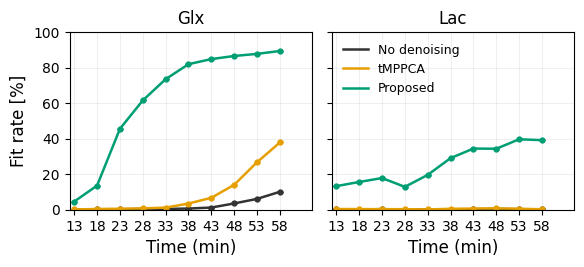

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- STYLE / COLORS (match plot_timecourse_metabolite_group) --------------------
DEFAULT_COLORS = {
    "noisy": "#333333",          # dark gray
    "tMPPCA_5D": "#E69F00",       # orange
    "deep_tMPPCA_5D": "#009E73",  # green
}
DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "o",        # keep 'o' to match timecourse style
    "deep_tMPPCA_5D": "o",   # keep 'o' to match timecourse style
}

def apply_example_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.grid": False,   # we set per-axis grid like in your function
    })

def suffix_from_method(method: str) -> str:
    # "P08_deep_tMPPCA_5D" -> "deep_tMPPCA_5D"
    return method.split("_", 1)[1] if "_" in method else method

# -------------------- FIT-RATE PIPELINE --------------------
def _suffix(quality_clip: bool, outlier_clip: bool) -> str:
    return "OutlierClip" if outlier_clip else ("QualityClip" if quality_clip else "Orig")

def load_sd_map(
    metabolite: str,
    method: str,
    *,
    data_dir: str = "MetabMaps",
    quality_clip: bool = False,
    outlier_clip: bool = False,
) -> np.ndarray:
    suffix = _suffix(quality_clip, outlier_clip)
    f_sd = os.path.join(data_dir, method, f"{metabolite}_sd_{method}_{suffix}.npy")
    if not os.path.isfile(f_sd):
        raise FileNotFoundError(f"SD map missing: {f_sd}")
    sd = np.load(f_sd)
    if sd.ndim != 4:
        raise ValueError(f"Unexpected SD shape {sd.shape}, expected (X,Y,Z,T).")
    return sd

def load_brain_mask(
    subject: str,
    *,
    tissue_dir: str = "../datasets",
) -> np.ndarray:
    mask_path = os.path.join(tissue_dir, subject, "mask.npy")
    if not os.path.isfile(mask_path):
        raise FileNotFoundError(f"Brain mask missing: {mask_path}")
    brain_mask = np.swapaxes(np.load(mask_path), 0, -1) > 0
    return brain_mask

def fit_rate_from_sd(
    sd_4d: np.ndarray,
    brain_mask: np.ndarray,
    *,
    crlb_thresh: float = 30.0,
) -> np.ndarray:
    if sd_4d.shape[:3] != brain_mask.shape:
        raise ValueError(f"Brain mask shape {brain_mask.shape} does not match SD map {sd_4d.shape[:3]}")
    T = sd_4d.shape[-1]
    rates = np.zeros(T, dtype=float)
    denom = brain_mask.sum()
    if denom == 0:
        return np.full(T, np.nan)
    for t in range(T):
        sd_t = sd_4d[..., t]
        ok = (sd_t <= crlb_thresh) & np.isfinite(sd_t) & brain_mask
        rates[t] = 100.0 * ok.sum() / denom
    return rates

def fit_rate_for_methods(
    metabolite: str,
    methods: list[str],
    subject: str,
    *,
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    quality_clip: bool = False,
    outlier_clip: bool = False,
    crlb_thresh: float = 30.0,
) -> dict[str, np.ndarray]:
    brain_mask = load_brain_mask(subject, tissue_dir=tissue_dir)
    out = {}
    for m in methods:
        sd = load_sd_map(
            metabolite, m,
            data_dir=data_dir,
            quality_clip=quality_clip,
            outlier_clip=outlier_clip,
        )
        out[m] = fit_rate_from_sd(sd, brain_mask, crlb_thresh=crlb_thresh)
    return out

def fit_rate_group_stats(
    metabolite: str,
    subjects: list[str],
    *,
    method_suffixes: list[str],
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    crlb_thresh: float = 30.0,
    quality_clip: bool = False,
    outlier_clip: bool = False,
    strict: bool = False,
) -> dict[str, dict[str, np.ndarray]]:
    per_method = {suf: [] for suf in method_suffixes}
    for subj in subjects:
        methods = [f"{subj}_{suf}" for suf in method_suffixes]
        try:
            rates_dict = fit_rate_for_methods(
                metabolite, methods, subj,
                data_dir=data_dir,
                tissue_dir=tissue_dir,
                quality_clip=quality_clip,
                outlier_clip=outlier_clip,
                crlb_thresh=crlb_thresh,
            )
        except Exception as e:
            if strict:
                raise
            print(f"[WARN] Skipping {subj} ({metabolite}): {e}")
            continue

        for suf, m in zip(method_suffixes, methods):
            per_method[suf].append(rates_dict[m])

    stats = {}
    for suf, series_list in per_method.items():
        if len(series_list) == 0:
            stats[suf] = {"mean": np.array([np.nan]), "std": np.array([np.nan]), "n": np.array([0])}
            continue
        arr = np.stack(series_list, axis=0)  # (Nsub, T)
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(mean)
        n    = np.sum(np.isfinite(arr), axis=0)
        stats[suf] = {"mean": mean, "std": std, "n": n}
    return stats

# -------------------- FINAL PLOT (match plot_timecourse_metabolite_group style) --------------------
def plot_group_fitrate_two_metabs_timecourse_style(
    *,
    stats_metab1: dict[str, dict[str, np.ndarray]],
    stats_metab2: dict[str, dict[str, np.ndarray]],
    methods: list[str],
    labels: list[str],
    time_minutes: np.ndarray,
    y_label: str = "Fit rate [%]",
    x_label: str = "Time (min)",
    metab1_title: str = "Glx",
    metab2_title: str = "Lac",
    ymax: float = 100.0,
    title: str = "",
    savepath: str | None = None,
    colors_by_suffix: dict[str, str] | None = None,
    markers_by_suffix: dict[str, str] | None = None,
    legend_loc: str = "upper left",
    legend_fontsize: int = 9,   # like your timecourse function
):
    assert len(methods) == len(labels), "methods and labels must have same length"
    apply_example_style()

    if colors_by_suffix is None:
        colors_by_suffix = DEFAULT_COLORS
    if markers_by_suffix is None:
        markers_by_suffix = DEFAULT_MARKERS

    method_suffixes = [suffix_from_method(m) for m in methods]
    colors  = [colors_by_suffix.get(suf, "#333333") for suf in method_suffixes]
    markers = [markers_by_suffix.get(suf, "o") for suf in method_suffixes]

    # --- sanity check T ---
    T = stats_metab1[method_suffixes[0]]["mean"].shape[0]
    if len(time_minutes) != T:
        raise ValueError(f"time_minutes length ({len(time_minutes)}) must match T ({T})")

    # --- style numbers from plot_timecourse_metabolite_group ---
    lw, ms, cap = 1.8, 3.5, 2
    elw = 1.0

    scale = 0.66

    fig, axes = plt.subplots(1, 2, figsize=(scale*9.0, scale*4.2), sharey=True, squeeze=False)
    ax1, ax2 = axes[0, 0], axes[0, 1]

    def _panel(ax, stats, panel_title):
        for suf, col, mk, lab in zip(method_suffixes, colors, markers, labels):
            y = stats[suf]["mean"]
            e = stats[suf]["std"]
            ax.errorbar(
                time_minutes, y, yerr=e,
                color=col,
                linestyle="-",
                marker=mk,
                lw=lw, ms=ms,
                capsize=cap,
                elinewidth=elw,
                label=lab
            )
        ax.set_title(panel_title)
        ax.set_xlabel(x_label)
        ax.set_ylim(0, ymax)
        ax.set_yticks(np.arange(0, ymax + 1, 20))
        ax.grid(True, alpha=0.2)
        ax.set_xticks(time_minutes)
        ax.set_xlim(12, 65)

    _panel(ax1, stats_metab1, metab1_title)
    _panel(ax2, stats_metab2, metab2_title)

    ax1.set_ylabel(y_label)

    # Legend (like your timecourse code: simple handles, frameoff)
    handles = [
        Line2D([0], [0], color=colors_by_suffix.get(suf, "k"), lw=lw, label=lab)
        for suf, lab in zip(method_suffixes, labels)
    ]
    ax2.legend(handles=handles, loc=legend_loc, frameon=False, fontsize=legend_fontsize)

    if title:
        fig.suptitle(title)

    plt.tight_layout()

    if savepath:
        if not savepath.lower().endswith(".pdf"):
            savepath += ".pdf"
        plt.savefig(savepath, bbox_inches="tight")
        print(f"💾 Saved as: {savepath}")

    plt.show()


# ===================== EXAMPLE: compute stats + plot (copy-paste runnable) =====================
subjects = ["Tumor_1"]
method_suffixes = ["noisy", "tMPPCA_5D", "deep_tMPPCA_5D"]

stats_lac = fit_rate_group_stats("Lac", subjects, method_suffixes=method_suffixes, crlb_thresh=30)
stats_glx = fit_rate_group_stats("Glx", subjects, method_suffixes=method_suffixes, crlb_thresh=30)

# Methods used ONLY for ordering/color mapping here (like in your earlier code)
methods = ["P08_noisy", "P08_tMPPCA_5D", "P08_deep_tMPPCA_5D"]
labels  = ["No denoising", "tMPPCA", "Proposed"]

# Provide time axis explicitly (same philosophy as plot_timecourse_metabolite_group)
# Example: 5 min per rep, starting at 13 min like your tumor panel in the PDF
time_minutes = np.array([13, 18, 23, 28, 33, 38, 43, 48, 53, 58], dtype=float)

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


plot_group_fitrate_two_metabs_timecourse_style(
    stats_metab1=stats_glx,
    stats_metab2=stats_lac,
    methods=methods,
    labels=labels,
    time_minutes=time_minutes,
    y_label="Fit rate [%]",
    x_label="Time (min)",
    metab1_title="Glx",
    metab2_title="Lac",
    ymax=100,
    title="",
    savepath="fitrate_group_two_panels_timecourse_style",
    legend_loc="upper left",
    legend_fontsize=9,
)



💾 Saved as: fitrate_2x2.pdf


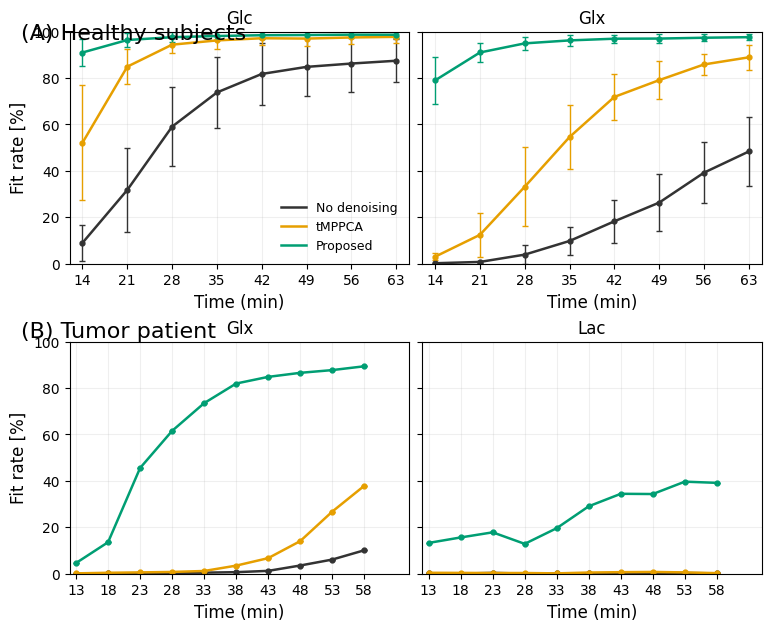

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# -------------------- STYLE / COLORS (match plot_timecourse_metabolite_group) --------------------
DEFAULT_COLORS = {
    "noisy": "#333333",          # dark gray
    "tMPPCA_5D": "#E69F00",       # orange
    "deep_tMPPCA_5D": "#009E73",  # green
}
DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "o",
    "deep_tMPPCA_5D": "o",
}

def apply_example_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.grid": False,
    })

def suffix_from_method(method: str) -> str:
    return method.split("_", 1)[1] if "_" in method else method

# -------------------- FIT-RATE PIPELINE --------------------
def _suffix(quality_clip: bool, outlier_clip: bool) -> str:
    return "OutlierClip" if outlier_clip else ("QualityClip" if quality_clip else "Orig")

def load_sd_map(
    metabolite: str,
    method: str,
    *,
    data_dir: str = "MetabMaps",
    quality_clip: bool = False,
    outlier_clip: bool = False,
) -> np.ndarray:
    suffix = _suffix(quality_clip, outlier_clip)
    f_sd = os.path.join(data_dir, method, f"{metabolite}_sd_{method}_{suffix}.npy")
    if not os.path.isfile(f_sd):
        raise FileNotFoundError(f"SD map missing: {f_sd}")
    sd = np.load(f_sd)
    if sd.ndim != 4:
        raise ValueError(f"Unexpected SD shape {sd.shape}, expected (X,Y,Z,T).")
    return sd

def load_brain_mask(
    subject: str,
    *,
    tissue_dir: str = "../datasets",
) -> np.ndarray:
    mask_path = os.path.join(tissue_dir, subject, "mask.npy")
    if not os.path.isfile(mask_path):
        raise FileNotFoundError(f"Brain mask missing: {mask_path}")
    brain_mask = np.swapaxes(np.load(mask_path), 0, -1) > 0
    return brain_mask

def fit_rate_from_sd(
    sd_4d: np.ndarray,
    brain_mask: np.ndarray,
    *,
    crlb_thresh: float = 30.0,
) -> np.ndarray:
    if sd_4d.shape[:3] != brain_mask.shape:
        raise ValueError(f"Brain mask shape {brain_mask.shape} does not match SD map {sd_4d.shape[:3]}")
    T = sd_4d.shape[-1]
    rates = np.zeros(T, dtype=float)
    denom = brain_mask.sum()
    if denom == 0:
        return np.full(T, np.nan)
    for t in range(T):
        sd_t = sd_4d[..., t]
        ok = (sd_t <= crlb_thresh) & np.isfinite(sd_t) & brain_mask
        rates[t] = 100.0 * ok.sum() / denom
    return rates

def fit_rate_for_methods(
    metabolite: str,
    methods: list[str],
    subject: str,
    *,
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    quality_clip: bool = False,
    outlier_clip: bool = False,
    crlb_thresh: float = 30.0,
) -> dict[str, np.ndarray]:
    brain_mask = load_brain_mask(subject, tissue_dir=tissue_dir)
    out = {}
    for m in methods:
        sd = load_sd_map(
            metabolite, m,
            data_dir=data_dir,
            quality_clip=quality_clip,
            outlier_clip=outlier_clip,
        )
        out[m] = fit_rate_from_sd(sd, brain_mask, crlb_thresh=crlb_thresh)
    return out

def fit_rate_group_stats(
    metabolite: str,
    subjects: list[str],
    *,
    method_suffixes: list[str],
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    crlb_thresh: float = 30.0,
    quality_clip: bool = False,
    outlier_clip: bool = False,
    strict: bool = False,
) -> dict[str, dict[str, np.ndarray]]:
    per_method = {suf: [] for suf in method_suffixes}
    for subj in subjects:
        methods = [f"{subj}_{suf}" for suf in method_suffixes]
        try:
            rates_dict = fit_rate_for_methods(
                metabolite, methods, subj,
                data_dir=data_dir,
                tissue_dir=tissue_dir,
                quality_clip=quality_clip,
                outlier_clip=outlier_clip,
                crlb_thresh=crlb_thresh,
            )
        except Exception as e:
            if strict:
                raise
            print(f"[WARN] Skipping {subj} ({metabolite}): {e}")
            continue

        for suf, m in zip(method_suffixes, methods):
            per_method[suf].append(rates_dict[m])

    stats = {}
    for suf, series_list in per_method.items():
        if len(series_list) == 0:
            stats[suf] = {"mean": np.array([np.nan]), "std": np.array([np.nan]), "n": np.array([0])}
            continue
        arr = np.stack(series_list, axis=0)  # (Nsub, T)
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(mean)
        n    = np.sum(np.isfinite(arr), axis=0)
        stats[suf] = {"mean": mean, "std": std, "n": n}
    return stats

# -------------------- 2x2 PLOT --------------------
def plot_fitrate_2x2(
    *,
    # Healthy
    stats_h_metab_left: dict[str, dict[str, np.ndarray]],
    stats_h_metab_right: dict[str, dict[str, np.ndarray]],
    time_h: np.ndarray,
    # Tumor
    stats_t_metab_left: dict[str, dict[str, np.ndarray]],
    stats_t_metab_right: dict[str, dict[str, np.ndarray]],
    time_t: np.ndarray,
    # Style / labels
    methods_for_style: list[str],
    labels: list[str],
    panelA_title: str = "(A) Healthy subjects",
    panelB_title: str = "(B) Tumor patient",
    top_left_title: str = "Glc",
    top_right_title: str = "Glx",
    bot_left_title: str = "Glx",
    bot_right_title: str = "Lac",
    y_label: str = "Fit rate [%]",
    x_label: str = "Time (min)",
    ymax: float = 100.0,
    xlim_common: tuple[float, float] | None = (12.0, 65.0),
    savepath: str | None = None,
    legend_loc: str = "lower right",
    legend_fontsize: int = 9,
):
    apply_example_style()

    # paper-like font sizes (same idea as your timecourse plot)
    mpl.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
    })

    method_suffixes = [suffix_from_method(m) for m in methods_for_style]
    colors  = [DEFAULT_COLORS.get(suf, "#333333") for suf in method_suffixes]
    markers = [DEFAULT_MARKERS.get(suf, "o") for suf in method_suffixes]

    lw, ms, cap = 1.8, 3.5, 2
    elw = 1.0

    fig, ax = plt.subplots(2, 2, figsize=(7.6, 6.2), sharey=True, constrained_layout=True)

    def _plot_panel(ax_, stats, time_, title_):
        for suf, col, mk, lab in zip(method_suffixes, colors, markers, labels):
            y = stats[suf]["mean"]
            e = stats[suf]["std"]
            ax_.errorbar(
                time_, y, yerr=e,
                color=col, linestyle="-", marker=mk,
                lw=lw, ms=ms, capsize=cap, elinewidth=elw,
                label=lab
            )
        ax_.set_title(title_)
        ax_.set_xlabel(x_label)
        ax_.set_ylim(0, ymax)
        ax_.set_yticks(np.arange(0, ymax + 1, 20))
        ax_.grid(True, alpha=0.2)
        ax_.set_xticks(time_)
        if xlim_common is not None:
            ax_.set_xlim(*xlim_common)

    # top row: Healthy
    _plot_panel(ax[0, 0], stats_h_metab_left,  time_h, top_left_title)
    _plot_panel(ax[0, 1], stats_h_metab_right, time_h, top_right_title)

    # bottom row: Tumor
    _plot_panel(ax[1, 0], stats_t_metab_left,  time_t, bot_left_title)
    _plot_panel(ax[1, 1], stats_t_metab_right, time_t, bot_right_title)

    # y-label only on left column
    ax[0, 0].set_ylabel(y_label)
    ax[1, 0].set_ylabel(y_label)

    # legend: put it in top-left (A) lower-right (like your preferred)
    handles = [
        Line2D([0], [0], color=DEFAULT_COLORS.get(suf, "k"), lw=lw, label=lab)
        for suf, lab in zip(method_suffixes, labels)
    ]
    ax[0, 0].legend(handles=handles, frameon=False, loc=legend_loc, fontsize=legend_fontsize)

    # row labels (A) and (B) at left, outside axes
    fig.text(0.02, 0.97, panelA_title, ha="left", va="top", fontsize=16)
    fig.text(0.02, 0.49, panelB_title, ha="left", va="top", fontsize=16)

    if savepath:
        if not savepath.lower().endswith(".pdf"):
            savepath += ".pdf"
        plt.savefig(savepath, bbox_inches="tight")
        print(f"💾 Saved as: {savepath}")

    plt.show()


# ===================== EXAMPLE: compute stats + 2x2 plot =====================

# ---- Healthy group ----
subjects_healthy = ["P03", "P04", "P05", "P06", "P07", "P08"]
method_suffixes = ["noisy", "tMPPCA_5D", "deep_tMPPCA_5D"]

stats_h_glc = fit_rate_group_stats("Glc", subjects_healthy, method_suffixes=method_suffixes, crlb_thresh=30)
stats_h_glx = fit_rate_group_stats("Glx", subjects_healthy, method_suffixes=method_suffixes, crlb_thresh=30)

time_h = np.array([14, 21, 28, 35, 42, 49, 56, 63], dtype=float)  # <- adapt if needed

# ---- Tumor patient ----
subjects_tumor = ["Tumor_1"]

stats_t_glx = fit_rate_group_stats("Glx", subjects_tumor, method_suffixes=method_suffixes, crlb_thresh=30)
stats_t_lac = fit_rate_group_stats("Lac", subjects_tumor, method_suffixes=method_suffixes, crlb_thresh=30)

time_t = np.array([13, 18, 23, 28, 33, 38, 43, 48, 53, 58], dtype=float)  # <- adapt if needed

# Style/order (just to define method suffix order)
methods_for_style = ["P08_noisy", "P08_tMPPCA_5D", "P08_deep_tMPPCA_5D"]
labels = ["No denoising", "t" + "MPPCA", "Proposed"]  # keep exact strings you want

plot_fitrate_2x2(
    stats_h_metab_left=stats_h_glc,
    stats_h_metab_right=stats_h_glx,
    time_h=time_h,
    stats_t_metab_left=stats_t_glx,
    stats_t_metab_right=stats_t_lac,
    time_t=time_t,
    methods_for_style=methods_for_style,
    labels=labels,
    panelA_title="(A) Healthy subjects",
    panelB_title="(B) Tumor patient",
    top_left_title="Glc",
    top_right_title="Glx",
    bot_left_title="Glx",
    bot_right_title="Lac",
    xlim_common=(12, 65),
    savepath="fitrate_2x2",
    legend_loc="lower right",
    legend_fontsize=9,
)
